In [1]:
from tempfile import TemporaryDirectory
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.models as mode
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader

In [2]:
if not 'd_fmnist' in locals():
    d_fmnist = TemporaryDirectory(prefix='Fashion-MNIST')

In [3]:
train_dataset = datasets.FashionMNIST(root=d_fmnist.name, train=True, download=True, transform=T.ToTensor())
test_dataset = datasets.FashionMNIST(root=d_fmnist.name, train=False, download=True, transform=T.ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.4MB/s]


Extracting /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw/train-images-idx3-ubyte.gz to /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 905kB/s]

Extracting /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw/train-labels-idx1-ubyte.gz to /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 15.5MB/s]


Extracting /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 16.9MB/s]

Extracting /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to /var/folders/j0/tr2332417vjbmj74tfc0dcd40000gn/T/Fashion-MNISToejmhs00/FashionMNIST/raw



In [6]:
len(train_dataset), len(test_dataset)

(60000, 10000)

In [21]:
images, _ = next(iter(train_dataset))
mean = images.mean()
std = images.std()
mean, std

(tensor(0.3814), tensor(0.3994))

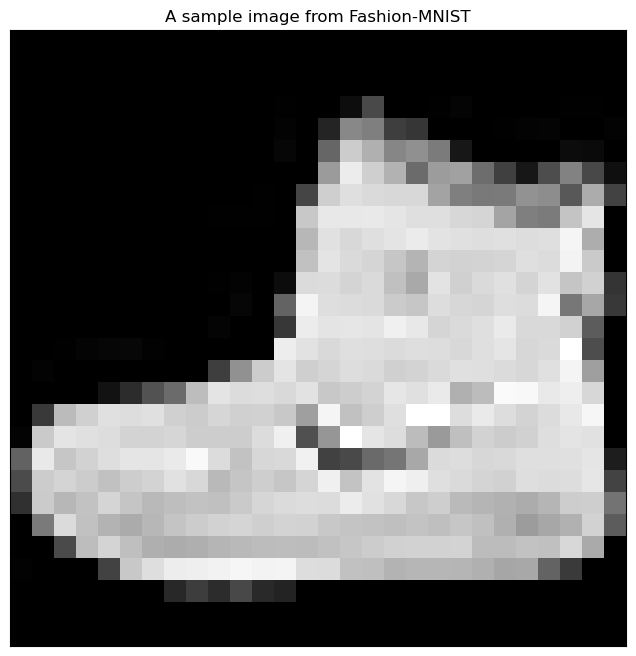

In [10]:
# Plot an image
import numpy as np
def show_img(im, ax=None, figsize=(8,8), title=None):
    if not ax: _,ax = plt.subplots(1,1,figsize=figsize)
    if len(im.shape)==2: im = np.tile(im[:,:,None], 3)
    ax.imshow(im);
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    if title: ax.set_title(title)
    return ax
show_img(images.numpy().squeeze(), title='A sample image from Fashion-MNIST');

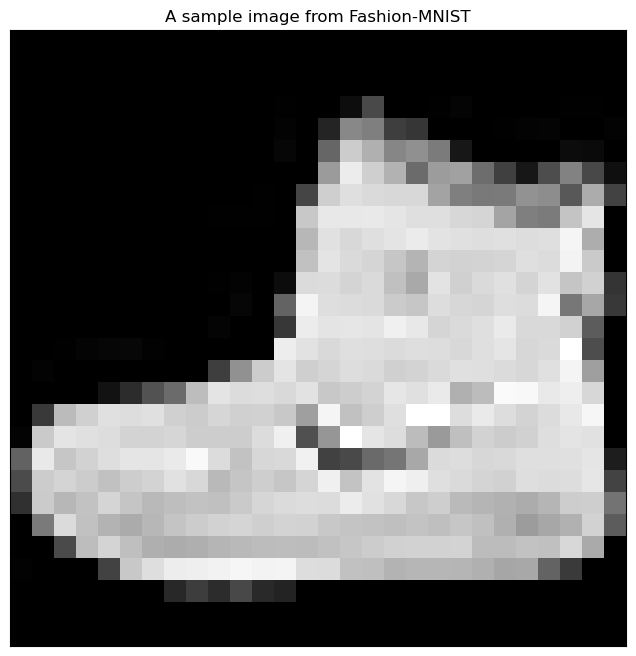

In [22]:
images = images.repeat(3,1,1) # Convert to 3 channels
show_img(images.numpy().transpose(1,2,0), title='A sample image from Fashion-MNIST');

In [23]:
train_loader = DataLoader(train_dataset, batch_size=60000)
images, _ = next(iter(train_loader))
mean = images.mean()
std = images.std()

In [24]:
mean, std

(tensor(0.2860), tensor(0.3530))

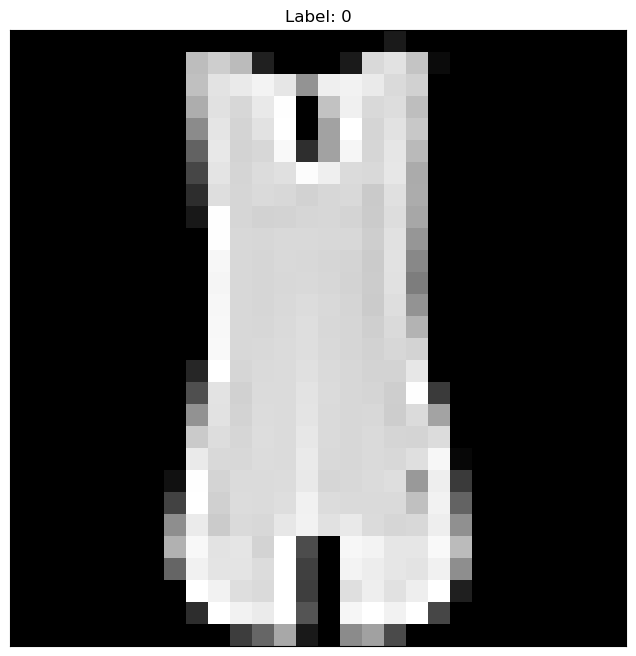

In [35]:
img, label = train_dataset[4]
show_img(img.squeeze(dim=0), title=f'Label: {label}');